# B-spline Opti Demo

This notebook demonstrates optimizing B-spline control points while evaluating constraints and objectives on the sampled output vector.

In [2]:
!pip install aerosandbox[full]

In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd()
while repo_root.name != "AeroSandbox" and repo_root != repo_root.parent:
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import aerosandbox as asb
import aerosandbox.numpy as np
import matplotlib.pyplot as plt

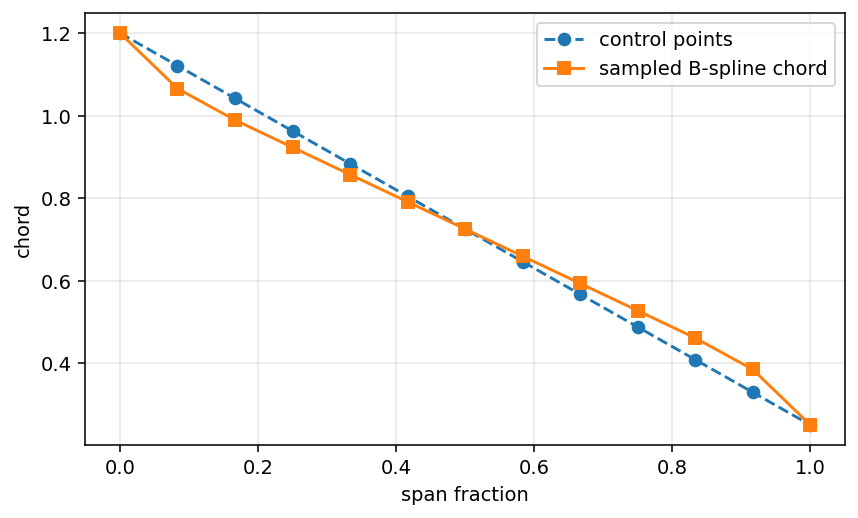

In [2]:
n_stations = 13
span_fraction = np.linspace(0, 1, n_stations)

# These are the values the optimizer directly changes.
initial_chord_control_points = np.linspace(1.2, 0.25, n_stations)

# These are the values that geometry, VLM, constraints, and objectives see.
initial_chord = asb.bspline(
    x=span_fraction,
    y_control_points=initial_chord_control_points,
    degree=3,
)

basis = asb.bspline_basis_matrix(
    x=span_fraction,
    n_control_points=n_stations,
    degree=3,
)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(span_fraction, initial_chord_control_points, "o--", label="control points")
plt.plot(span_fraction, initial_chord, "s-", label="sampled B-spline chord")
plt.xlabel("span fraction")
plt.ylabel("chord")
plt.grid(True, alpha=0.3)
plt.legend();

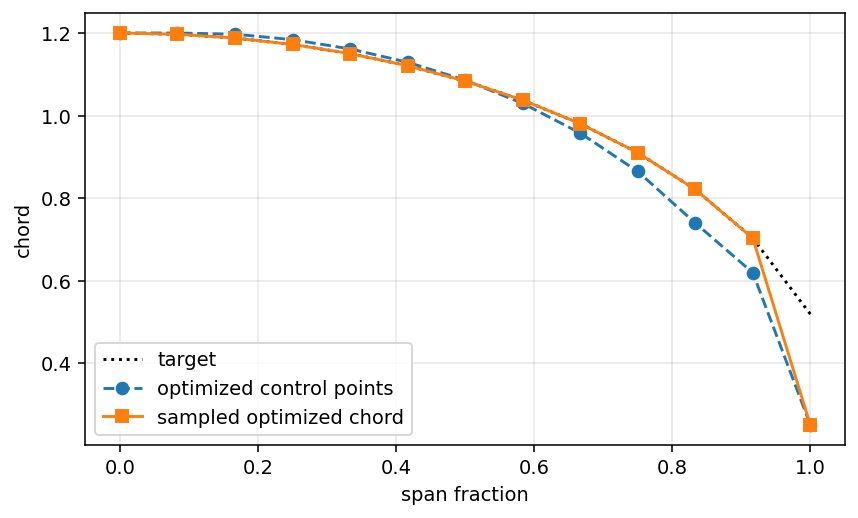

In [3]:
opti = asb.Opti()

chord_control_points = opti.variable(
    init_guess=initial_chord_control_points,
    lower_bound=0.15,
    upper_bound=1.6,
)

chord = asb.bspline(
    x=span_fraction,
    y_control_points=chord_control_points,
    degree=3,
)

# Example geometry-style constraints evaluated on the sampled chord vector.
opti.subject_to([
    chord[0] == 1.2,
    chord[-1] == 0.25,
    chord[1:] <= chord[:-1],
])

# Example target: an elliptic-ish chord distribution. Replace this with VLM-derived objectives as needed.
target_chord = 0.25 + 0.95 * np.sqrt(1 - 0.92 * span_fraction ** 2)
target_chord_column = np.reshape(target_chord, (-1, 1))
opti.minimize(np.sum((chord - target_chord_column) ** 2))

sol = opti.solve(verbose=False)

optimized_control_points = sol(chord_control_points)
optimized_chord = sol(chord)

plt.figure(figsize=(7, 4), dpi=140)
plt.plot(span_fraction, target_chord, "k:", label="target")
plt.plot(span_fraction, optimized_control_points, "o--", label="optimized control points")
plt.plot(span_fraction, optimized_chord, "s-", label="sampled optimized chord")
plt.xlabel("span fraction")
plt.ylabel("chord")
plt.grid(True, alpha=0.3)
plt.legend();

In [4]:
print("basis matrix shape:", basis.shape)
print("output vector length:", len(optimized_chord))
print("control vector length:", len(optimized_control_points))
print("basis matrix rank:", np.linalg.matrix_rank(basis))

basis matrix shape: (13, 13)
output vector length: 13
control vector length: 13
basis matrix rank: 13
